# Multiquadric Quasi-Interpolation (MQQI) for Burgers' Equation


---

### Mathematical Summary

Burgers' equation (with viscosity):
$$u_t + u u_x = \frac{1}{R} u_{xx}, \quad 0 < x < 1, \quad t > 0$$

Boundary conditions:
$$u(0, t) = u(1, t) = 0$$

The spatial derivatives $(u_x)_j^n$ and $(u_{xx})_j^n$ are computed via the univariate Multiquadric (MQ) quasi-interpolation:
$$(u_x)_j^n = \frac{1}{2} \sum_{k=0}^{m-1} \frac{\phi_k'(x_j) - \phi_{k+1}'(x_j)}{x_{k+1} - x_k} (u_{k+1}^n - u_k^n)$$
$$(u_{xx})_j^n = \frac{1}{2} \sum_{k=0}^{m-1} \frac{\phi_k''(x_j) - \phi_{k+1}''(x_j)}{x_{k+1} - x_k} (u_{k+1}^n - u_k^n)$$

where:
$$\phi_k(x) = \sqrt{(x - x_k)^2 + \lambda^2}, \quad 0 \le k \le m-1$$
$$\phi_m(x) = \phi_0(x) - 2x + x_m + x_0$$

To damp dispersion, the switch function $g_j^n$ is introduced:
$$g_j^n = \max\{0, 1 + \min\{0, \operatorname{sign}((u_x)_j^n \cdot (u_x)_k^n)\}\}, \quad k = j - \operatorname{sign}(u_j^n)$$

Forward time stepping:
$$u_j^{n+1} = u_j^n - \tau \cdot u_j^n \cdot (u_x)_j^n \cdot g_j^n + \frac{\tau}{R} (u_{xx})_j^n$$


In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Ensure local package mqqi is importable
current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

from mqqi import (
    MQQIBurgersSolver,
    get_problem_case,
    cole_analytic_solution,
    plot_paper_figure_1_to_3,
    plot_paper_figure_4,
)
from mqqi.problems import (
    PAPER_TABLE_1_DATA,
    PAPER_TABLE_2_DATA,
    PAPER_TABLE_3_DATA,
)

%matplotlib inline
%config InlineBackend.figure_format = 'retina'


## 1. Figure 1 & Table 1: $R = 10$

- **Initial condition:** $u(x, 0) = \sin(\pi x)$
- **Reynolds number:** $R = 10$
- **Spatial step:** $h = 1/100$ ($m = 100$)
- **Time step:** $\tau = 10^{-3}$ ($0.001$)
- **Shape parameter:** $\lambda = 0.0072$
- **Time snapshots:** $t = 0.0, 0.2, 0.4, 0.6, 0.8, 1.0$


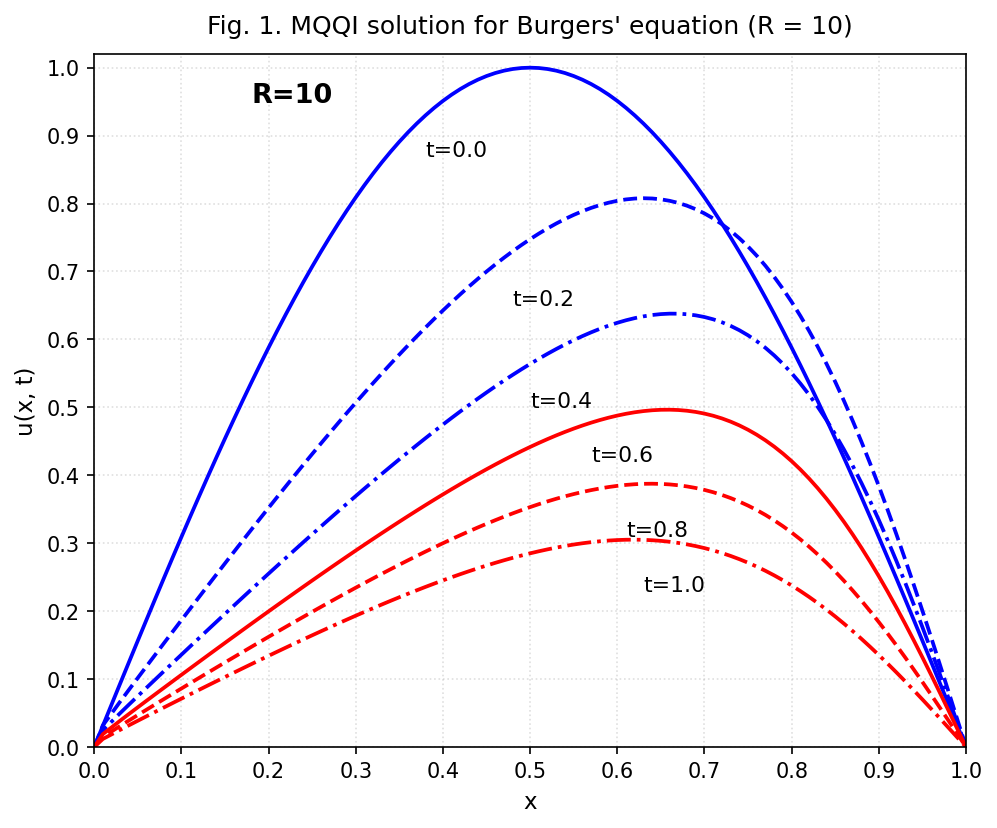

In [2]:
# Setup and solve Case 1 (R = 10)
case1 = get_problem_case("fig1")
solver1 = MQQIBurgersSolver(
    m=case1.m,
    tau=case1.tau,
    lam=case1.lam,
    R=case1.R,
    x_span=case1.x_span
)

x1, solutions1 = solver1.solve(
    u0=case1.u0_func,
    t_end=case1.t_end,
    record_times=case1.record_times
)

# Plot Figure 1
fig, ax = plt.subplots(figsize=(7.5, 6), dpi=150)
plot_paper_figure_1_to_3(x1, solutions1, R_value=case1.R, fig_num=1, ax=ax)
plt.show()


In [3]:
# Table 1: Comparison of results for R = 10 at t = 1.0
u1_t1 = solutions1[1.0]

print("=" * 80)
print("Table 1: Comparison of results for R = 10 at t = 1.0")
print("=" * 80)
print(f"{'x':>6} | {'Analytic':>10} | {'Hon & Mao':>10} | {'MQQI Paper':>12} | {'MQQI Computed':>14} | {'Rel Err (%)':>12}")
print("-" * 80)

for x_eval, (ana, hm, pap) in sorted(PAPER_TABLE_1_DATA.items()):
    idx = int(round(x_eval * case1.m))
    comp = u1_t1[idx]
    rel_err = abs(comp - ana) / ana * 100.0
    print(f"{x_eval:6.2f} | {ana:10.4f} | {hm:10.4f} | {pap:12.6f} | {comp:14.6f} | {rel_err:12.4f}")


Table 1: Comparison of results for R = 10 at t = 1.0
     x |   Analytic |  Hon & Mao |   MQQI Paper |  MQQI Computed |  Rel Err (%)
--------------------------------------------------------------------------------
  0.10 |     0.0663 |     0.0664 |     0.071238 |       0.071238 |       7.4480
  0.20 |     0.1312 |     0.1313 |     0.134310 |       0.134307 |       2.3679
  0.30 |     0.1928 |     0.1928 |     0.193390 |       0.193385 |       0.3035
  0.40 |     0.2480 |     0.2481 |     0.245380 |       0.245378 |       1.0572
  0.50 |     0.2919 |     0.2919 |     0.285170 |       0.285171 |       2.3052
  0.60 |     0.3161 |     0.3159 |     0.304730 |       0.304728 |       3.5977
  0.70 |     0.3081 |     0.3079 |     0.292880 |       0.292875 |       4.9416
  0.80 |     0.2537 |     0.2534 |     0.237840 |       0.237841 |       6.2509
  0.90 |     0.1461 |     0.1459 |     0.135420 |       0.135422 |       7.3088


## 2. Figure 2 & Table 2: $R = 100$

- **Initial condition:** $u(x, 0) = \sin(\pi x)$
- **Reynolds number:** $R = 100$
- **Spatial step:** $h = 1/100$ ($m = 100$)
- **Time step:** $\tau = 10^{-3}$ ($0.001$)
- **Shape parameter:** $\lambda = 0.0029$
- **Time snapshots:** $t = 0.0, 0.2, 0.4, 0.6, 0.8, 1.0$


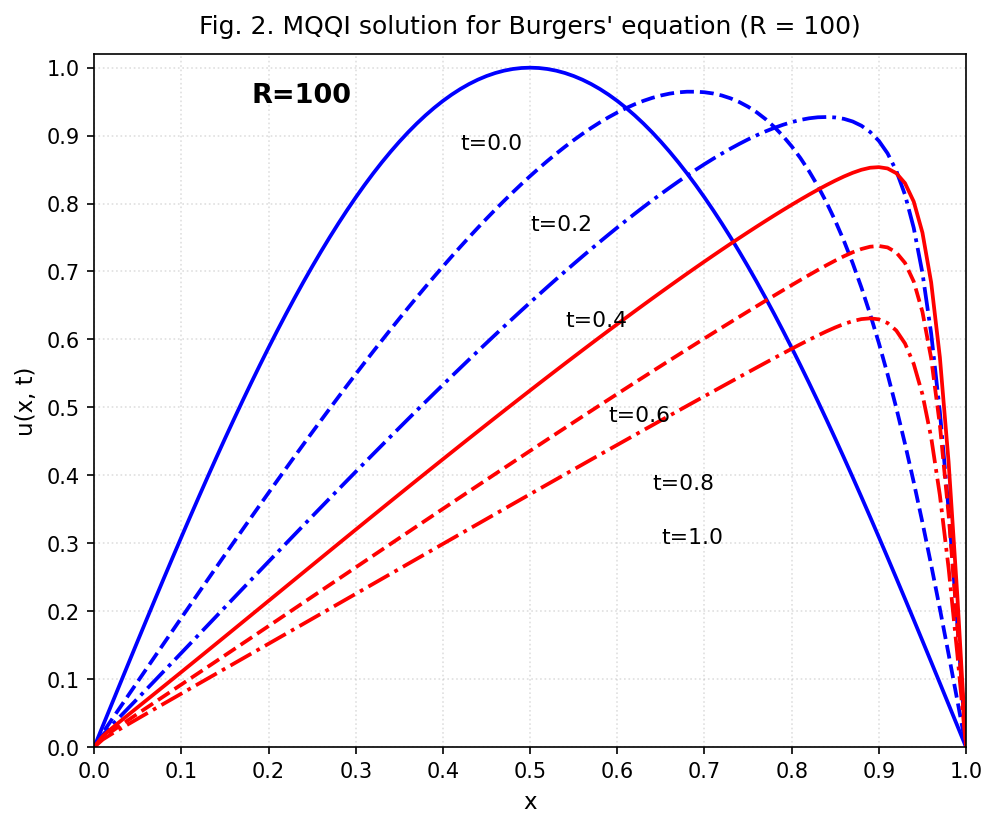

In [4]:
# Setup and solve Case 2 (R = 100)
case2 = get_problem_case("fig2")
solver2 = MQQIBurgersSolver(
    m=case2.m,
    tau=case2.tau,
    lam=case2.lam,
    R=case2.R,
    x_span=case2.x_span
)

x2, solutions2 = solver2.solve(
    u0=case2.u0_func,
    t_end=case2.t_end,
    record_times=case2.record_times
)

# Plot Figure 2
fig, ax = plt.subplots(figsize=(7.5, 6), dpi=150)
plot_paper_figure_1_to_3(x2, solutions2, R_value=case2.R, fig_num=2, ax=ax)
plt.show()


In [5]:
# Table 2: Comparison of results for R = 100 at t = 1.0
u2_t1 = solutions2[1.0]

print("=" * 80)
print("Table 2: Comparison of results for R = 100 at t = 1.0")
print("=" * 80)
print(f"{'x':>6} | {'Analytic':>10} | {'Hon & Mao':>10} | {'MQQI Paper':>12} | {'MQQI Computed':>14} | {'Rel Err (%)':>12}")
print("-" * 80)

for x_eval, (ana, hm, pap) in sorted(PAPER_TABLE_2_DATA.items()):
    idx = int(round(x_eval * case2.m))
    comp = u2_t1[idx]
    rel_err = abs(comp - ana) / ana * 100.0
    print(f"{x_eval:6.2f} | {ana:10.4f} | {hm:10.4f} | {pap:12.6f} | {comp:14.6f} | {rel_err:12.4f}")


Table 2: Comparison of results for R = 100 at t = 1.0
     x |   Analytic |  Hon & Mao |   MQQI Paper |  MQQI Computed |  Rel Err (%)
--------------------------------------------------------------------------------
  0.10 |     0.0754 |     0.0755 |     0.078675 |       0.078675 |       4.3439
  0.20 |     0.1506 |     0.1507 |     0.152020 |       0.152051 |       0.9634
  0.30 |     0.2257 |     0.2257 |     0.225540 |       0.225537 |       0.0721
  0.40 |     0.3003 |     0.3003 |     0.299040 |       0.299045 |       0.4181
  0.50 |     0.3744 |     0.3744 |     0.372260 |       0.372257 |       0.5724
  0.60 |     0.4478 |     0.4478 |     0.444840 |       0.444835 |       0.6620
  0.70 |     0.5203 |     0.5202 |     0.516430 |       0.516432 |       0.7434
  0.80 |     0.5915 |     0.5913 |     0.586220 |       0.586215 |       0.8935
  0.90 |     0.6600 |     0.6607 |     0.629560 |       0.629562 |       4.6118


## 3. Figure 3 & Table 3: $R = 10,000$

- **Initial condition:** $u(x, 0) = \sin(\pi x)$
- **Reynolds number:** $R = 10000$
- **Spatial step:** $h = 1/72$ ($m = 72$)
- **Time step:** $\tau = 10^{-3}$ ($0.001$)
- **Shape parameter:** $\lambda = 1.43 \times 10^{-4}$
- **Time snapshots:** $t = 0.0, 0.2, 0.4, 0.6, 0.8, 1.0$


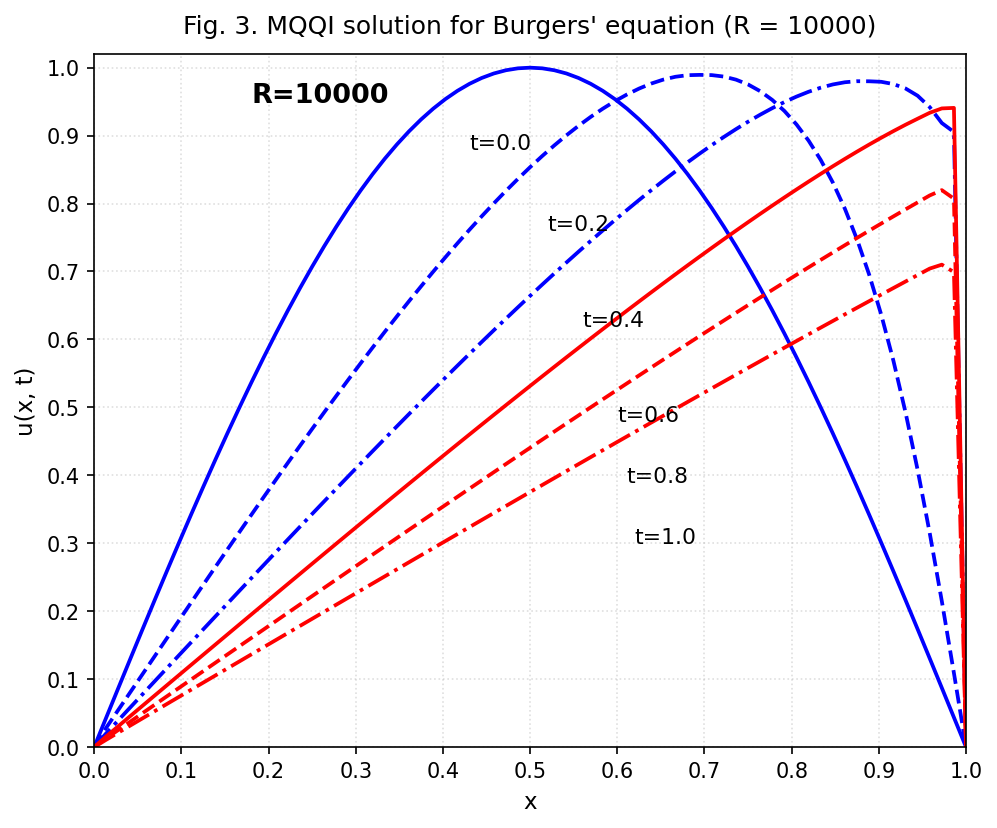

In [6]:
# Setup and solve Case 3 (R = 10000)
case3 = get_problem_case("fig3")
solver3 = MQQIBurgersSolver(
    m=case3.m,
    tau=case3.tau,
    lam=case3.lam,
    R=case3.R,
    x_span=case3.x_span
)

x3, solutions3 = solver3.solve(
    u0=case3.u0_func,
    t_end=case3.t_end,
    record_times=case3.record_times
)

# Plot Figure 3
fig, ax = plt.subplots(figsize=(7.5, 6), dpi=150)
plot_paper_figure_1_to_3(x3, solutions3, R_value=case3.R, fig_num=3, ax=ax)
plt.show()


In [7]:
# Table 3: Comparison of results for R = 10000 at t = 1.0
u3_t1 = solutions3[1.0]

print("=" * 70)
print("Table 3: Comparison of results for R = 10000 at t = 1.0")
print("=" * 70)
print(f"{'x':>8} | {'Christie':>10} | {'Hon & Mao':>10} | {'MQQI Paper':>12} | {'MQQI Computed':>14}")
print("-" * 70)

for x_eval, (chr_val, hm, pap) in sorted(PAPER_TABLE_3_DATA.items()):
    idx = int(round(x_eval * case3.m))
    comp = u3_t1[idx]
    print(f"{x_eval:8.3f} | {chr_val:10.4f} | {hm:10.4f} | {pap:12.6f} | {comp:14.6f}")


Table 3: Comparison of results for R = 10000 at t = 1.0
       x |   Christie |  Hon & Mao |   MQQI Paper |  MQQI Computed
----------------------------------------------------------------------
   0.056 |     0.0422 |     0.0424 |     0.042395 |       0.042395
   0.111 |     0.0843 |     0.0843 |     0.084337 |       0.084337
   0.167 |     0.1263 |     0.1263 |     0.126190 |       0.126187
   0.222 |     0.1684 |     0.1684 |     0.167960 |       0.167962
   0.278 |     0.2103 |     0.2103 |     0.209570 |       0.209666
   0.333 |     0.2522 |     0.2522 |     0.251290 |       0.251290
   0.389 |     0.2939 |     0.2939 |     0.292810 |       0.292811
   0.444 |     0.3355 |     0.3355 |     0.334200 |       0.334204
   0.500 |     0.3769 |     0.3769 |     0.375440 |       0.375436
   0.556 |     0.4182 |     0.4182 |     0.414680 |       0.416476
   0.611 |     0.4592 |     0.4592 |     0.457290 |       0.457287
   0.667 |     0.5000 |     0.4999 |     0.497830 |       0.497830
  

## 4. Figure 4: Shock Wave Development ($R = 10,000$)

- **Initial condition:** $u(x, 0) = \sin(2\pi x) + 0.5\sin(\pi x)$
- **Reynolds number:** $R = 10000$
- **Spatial step:** $h = 1/80$ ($m = 80$)
- **Time step:** $\tau = 10^{-3}$ ($0.001$)
- **Shape parameter:** $\lambda = 1.2 \times 10^{-4}$
- **Time snapshots:** $t = 0.2, 0.6, 1.0, 1.4, 2.0$


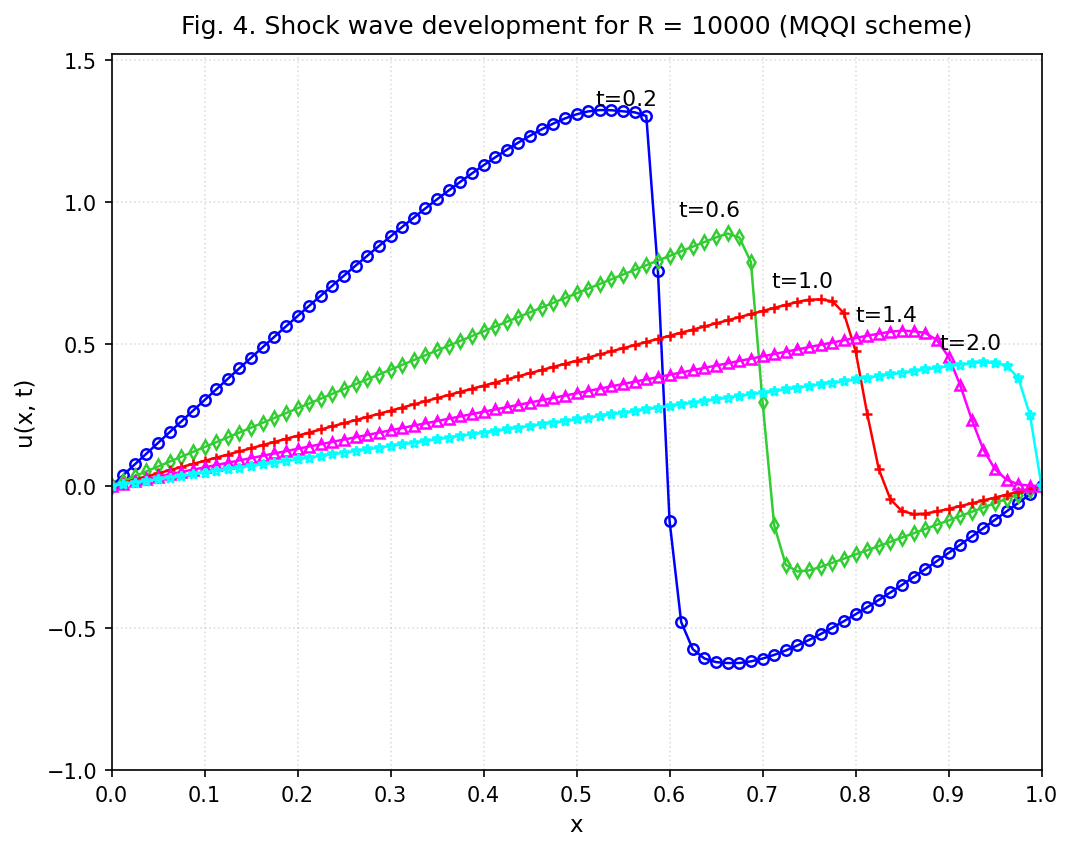

In [8]:
# Setup and solve Case 4 (Shock Wave)
case4 = get_problem_case("fig4")
solver4 = MQQIBurgersSolver(
    m=case4.m,
    tau=case4.tau,
    lam=case4.lam,
    R=case4.R,
    x_span=case4.x_span
)

x4, solutions4 = solver4.solve(
    u0=case4.u0_func,
    t_end=case4.t_end,
    record_times=case4.record_times
)

# Plot Figure 4
fig, ax = plt.subplots(figsize=(8, 6.2), dpi=150)
plot_paper_figure_4(x4, solutions4, fig_num=4, ax=ax)
plt.show()


## 5. Conclusions & Observations

1. **Efficiency**: By precomputing the Multiquadric quasi-interpolation differentiation matrices $A$ and $B$, each time step takes only $\mathcal{O}(m)$ operations without solving any matrix linear systems at each time step.
2. **Shock Capturing**: The switch function $g_j^n$ successfully prevents non-physical spurious oscillations near steep gradients and shock fronts (as demonstrated in Figure 4).
3. **High Accuracy at High $R$**: As noted in the paper, the scheme delivers high precision for convection-dominated regimes ($R = 100$ and $R = 10,000$).
